## Introduction
In the previous notebook, we used Singular Value Decomposition (SVD) to explore the structure of the 2D spectroscopic dataset and estimate the number of significant components contributing to the signal. As we mentioned before, while SVD provides a powerful mathematical decomposition of the data matrix, the resulting singular vectors are not guaranteed to correspond to chemically meaningful spectra or concentration profiles. So, to obtain interpretable information about the system, we now apply Multivariate Curve Resolution using Alternating Least Squares (MCR-ALS). 

MCR-ALS uses the same bilinear mixture model introduced previously, and as we already explained, for the 2D dataset, each spectrum must be reshaped into a vector so that the full dataset can be represented as a two-way matrix suitable for multivariate analysis. This allows the same MCR framework used for 1D spectra to be applied to the 2D case.

And remember, because MCR-ALS solutions are not mathematically unique, the application of chemically meaningful constraints is essential to obtain physically interpretable results.

## Loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymcr
from pymcr.mcr import McrAR
from pymcr.regressors import OLS, NNLS
from pymcr.constraints import Constraint, ConstraintNonneg, ConstraintNorm
from pymcr.metrics import mse
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import curve_fit



# load spectra
holo = pd.read_csv('../data/2D_holo_spectrum.csv', index_col=0)
intermediate = pd.read_csv('../data/2D_intermediate_spectrum.csv', index_col=0)
apo = pd.read_csv('../data/2D_apo_spectrum.csv', index_col=0)

# load spectra
dataset = np.load("../data/dataset_2D.npz")

data = dataset["D"]
H_ppm = dataset["H_ppm"]
N_ppm = dataset["N_ppm"]
time_points = dataset["time_points"]

## Reshape

In [3]:
print(data.shape)

(20, 120, 160)


In [4]:
data = data.reshape(len(time_points), -1)
print(data.shape)

(20, 19200)


# MCR
In this example, we are running the MCR using the spectra estimate. However, the concentration profile estimate can also be used, just remember to normalize it to avoid negative values and make it a better estimate.

In [6]:
components = [0, 4, -1]
estimated_spetra = np.stack([data[i] for i in components])

mcr = McrAR(max_iter=600, tol_increase=2, c_regr='OLS',
                st_regr='OLS', c_constraints=[ConstraintNonneg(), ConstraintNorm()])
# Included a non-negativity constraint because this type of spectra do not present a negative signal
#Included Sum-to-1 constraint (ConstraintNorm()), which imposes that after each iteration
# the summation of all concentrations for each data point sums-to-one.
mcr.fit(data, ST=estimated_spetra, verbose=False)
print('\nFinal MSE: {:.7e}'.format(mcr.err[-1]))

C = mcr.C_
ST = mcr.ST_

Max iterations reached (600).

Final MSE: 1.5078047e-05


# Components' spectra
Remember that the 2D spectra were flattened before performing the MCR analysis. As a consequence, the recovered component spectra are also obtained as flattened vectors. To interpret them as 2D spectra, each vector must be reshaped back to the original $(n_N \times n_H)$ dimensions.

In [8]:
nN, nH = holo.shape

rec_holo = ST[0].reshape(nN, nH)
rec_int  = ST[1].reshape(nN, nH)
rec_apo  = ST[2].reshape(nN, nH)

def normalize(S):
    return S / np.max(np.abs(S))

holo_n = normalize(holo)
int_n  = normalize(intermediate)
apo_n  = normalize(apo)

rec_holo_n = normalize(rec_holo)
rec_int_n  = normalize(rec_int)
rec_apo_n  = normalize(rec_apo)

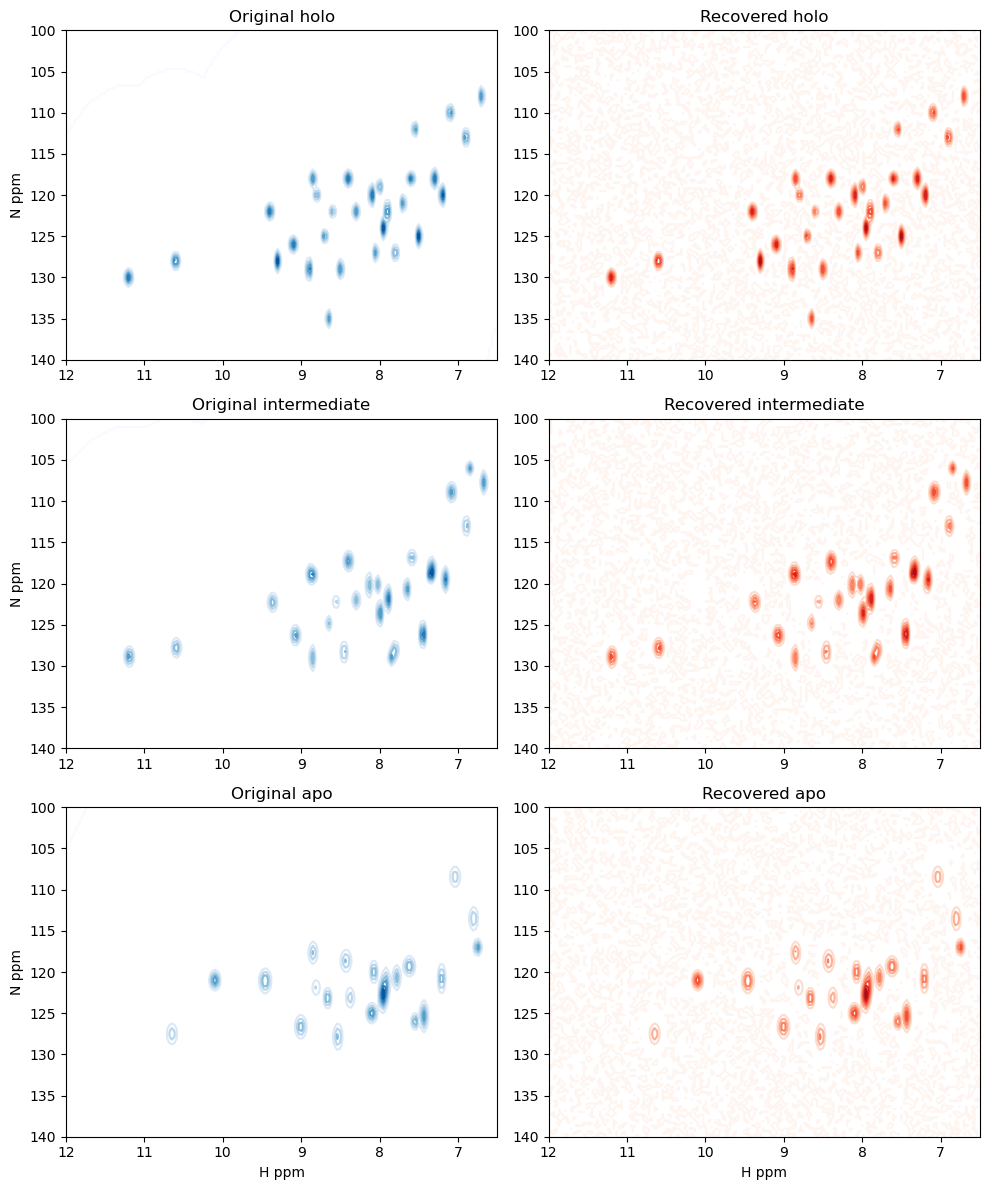

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

titles = [
    ("Original holo", "Recovered holo"),
    ("Original intermediate", "Recovered intermediate"),
    ("Original apo", "Recovered apo")
]

originals = [holo_n, int_n, apo_n]
recovered = [rec_holo_n, rec_int_n, rec_apo_n]

for i in range(3):
    im1 = axes[i,0].contour(H_ppm, N_ppm,
        originals[i],
        origin='lower',
        cmap='Blues'
    )
    axes[i,0].invert_xaxis()
    axes[i,0].invert_yaxis()
    
    im2 = axes[i,1].contour(H_ppm, N_ppm,
        recovered[i],
        origin='lower',
        cmap='Reds'
    )
    axes[i,1].invert_xaxis()
    axes[i,1].invert_yaxis()

    axes[i,0].set_title(titles[i][0])
    axes[i,1].set_title(titles[i][1])
    axes[2,0].set_xlabel("H ppm")
    axes[2,1].set_xlabel("H ppm")
    axes[i, 0].set_ylabel("N ppm")

plt.tight_layout()
plt.show()

The spectra obtained from the MCR analysis look incredibly similar to the original ones.

### Concentration Profiles

We can also see how the concentration profile aligns with the kinetic demetallation process modeled when creating the synthetic dataset.

Text(0.5, 1.0, 'MCR-ALS Retrieved')

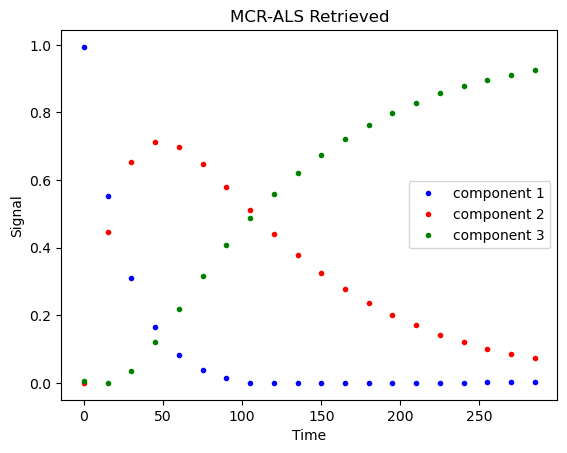

In [12]:
plt.plot(time_points, C.T[0,:], '.b', label="component 1")
plt.plot(time_points, C.T[1,:], '.r', label="component 2")
plt.plot(time_points, C.T[2,:], '.g', label="component 3")
plt.legend()
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('MCR-ALS Retrieved')

# Kinetic analysis

In [14]:
def curveA(t,k1,A0):
  y = A0*(np.exp(-k1*t))
  return y

def curveB(t,k1,k2,A0):
  y = ((k1*A0)/(k2-k1))*(np.exp(-k1*t)-np.exp(-k2*t))
  return y

def curveC(t,k1,k2,A0):
  y = A0*(1-(1/(k2-k1))*(k2*np.exp(-k1*t)-k1*np.exp(-k2*t)))
  return y

starting_k1 = (C.T[0,0]-C.T[0,1])/time_points[1]
starting_k2 = -(C.T[2,4]-C.T[2,5])/(time_points[5]-time_points[4])
fittedA, pcovA = curve_fit(curveA, time_points, C.T[0,:], [starting_k1, 1])
fittedB, pcovB = curve_fit(curveB, time_points, C.T[1,:], [starting_k1, starting_k2, 1])
fittedC, pcovC = curve_fit(curveC, time_points, C.T[2,:], [starting_k1, starting_k2, 1])

In [15]:
print(f'''
k1 from component 1: {fittedA[0]:.3f}, error: {np.sqrt(np.diag(pcovA))[0]:.4f}
k1 from component 2: {fittedB[0]:.3f}, error: {np.sqrt(np.diag(pcovB))[0]:.4f}
k1 from component 2: {fittedC[0]:.3f}, error: {np.sqrt(np.diag(pcovB))[0]:.4f}''')


k1 from component 1: 0.040, error: 0.0005
k1 from component 2: 0.034, error: 0.0002
k1 from component 2: 0.015, error: 0.0002


In [16]:
print(f'''
k2 from component 2: {fittedB[1]:.3f}, error: {np.sqrt(np.diag(pcovB))[1]:.4f}
k2 from component 2: {fittedC[1]:.3f}, error: {np.sqrt(np.diag(pcovB))[1]:.4f}''')


k2 from component 2: 0.011, error: 0.0000
k2 from component 2: 0.015, error: 0.0000


In [17]:
holo_fitted = curveA(time_points, fittedA[0], fittedA[1])
int_fitted = curveB(time_points, fittedB[0], fittedB[1], fittedB[2])
apo_fitted = curveC(time_points, fittedC[0], fittedC[1], fittedC[2])

Text(0.5, 1.0, 'Fit to kinetic equation')

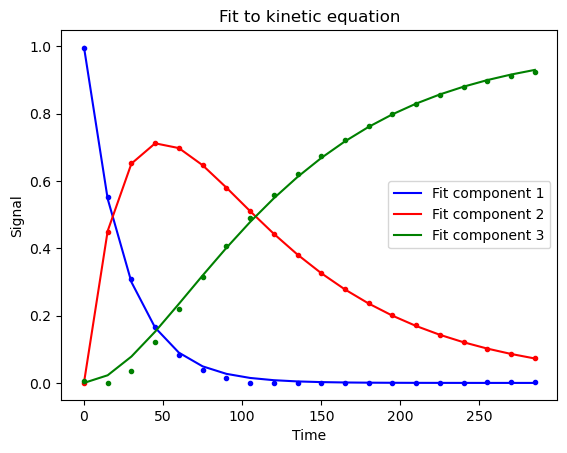

In [18]:
plt.plot(time_points, C.T[0,:], '.b')
plt.plot(time_points, holo_fitted, "-b", label = 'Fit component 1')
plt.plot(time_points, C.T[1,:], '.r')
plt.plot(time_points, int_fitted, "-r", label = 'Fit component 2')
plt.plot(time_points, C.T[2,:], '.g')
plt.plot(time_points, apo_fitted, "-g", label = 'Fit component 3')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Fit to kinetic equation')

Text(0.5, 1.0, 'Residuals plot')

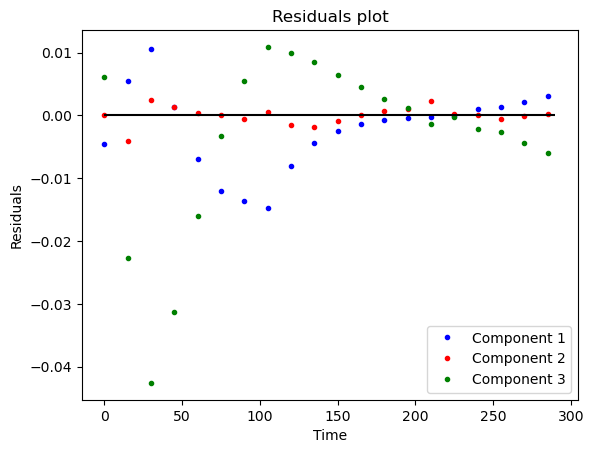

In [19]:
plt.plot(time_points, C.T[0,:]-holo_fitted, '.b', label = 'Component 1')
plt.plot(time_points, C.T[1,:]-int_fitted, ".r", label = 'Component 2')
plt.plot(time_points, C.T[2,:]-apo_fitted, ".g", label = 'Component 3')
plt.hlines(0, 0, 290, colors='black')
plt.legend()
plt.xlabel('Time')
plt.ylabel("Residuals")
plt.title("Residuals plot")

The kinetic parameters obtained from the 2D MCR analysis are generally consistent with the values used to generate the simulated data.

For the first component, the fitted value $k_1$ = 0.040 is close to the true value ($k_1$ = 0.035), showing that the concentration profile recovered by MCR captures the main kinetic behavior of the species.

The second component provides the most accurate results, with fitted values $k_1$ = 0.034 and $k_2$ = 0.011, which closely match the true rate constants. This is expected because the intermediate species contains information about both kinetic processes and therefore strongly constrains the fit.

In contrast, the third component does not reproduce the correct parameters, fitting to $k_1$=0.015 and $k_2$=0.015. This discrepancy, as we mentioned for the 1D data, arises because the concentration of this species is very low at the early stages of the reaction. In the presence of noise, small errors in the estimated concentration profile can have a large relative effect, making the kinetic fit less reliable.

Despite these limitations, the overall agreement between the recovered and true parameters indicates that the 2D dataset provides sufficient information for MCR to recover chemically meaningful concentration profiles.